In [1]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [2]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
bike_df = pd.read_csv('../data/BikeIndia.csv')
bike_df.shape

(730, 16)

In [6]:
bike_df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    str    
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.4 KB


In [8]:
bike_df_copy = bike_df.copy()

audit_df = pd.DataFrame({
    'dtype': bike_df_copy.dtypes.astype(str),
    'missing_count': bike_df_copy.isna().sum(),
    'missing_pct': (bike_df_copy.isna().mean() * 100).round(2),
    'unique_values': bike_df_copy.nunique()
}).sort_values(['missing_count', 'dtype'], ascending=[False, True])
audit_df

,dtype,missing_count,missing_pct,unique_values
temp,float64,0,0.0,498
atemp,float64,0,0.0,689
hum,float64,0,0.0,594
windspeed,float64,0,0.0,649
instant,int64,0,0.0,730
season,int64,0,0.0,4
yr,int64,0,0.0,2
mnth,int64,0,0.0,12
holiday,int64,0,0.0,2
weekday,int64,0,0.0,7


In [10]:
print(f'Duplicate rows: {bike_df_copy.duplicated().sum()}')
display(audit_df)
display(bike_df_copy.describe(include='all').T)

numeric_cols = bike_df_copy.select_dtypes(include=np.number).columns.tolist()
categorical_cols = bike_df_copy.select_dtypes(exclude=np.number).columns.tolist()
target_col = 'cnt'

if bike_df_copy.isna().sum().sum() == 0:
    print('No missing values found, so no imputation is required.')
else:
    print('Missing values detected. Median/mode imputation should be applied before modeling.')

Duplicate rows: 0


,dtype,missing_count,missing_pct,unique_values
temp,float64,0,0.0,498
atemp,float64,0,0.0,689
hum,float64,0,0.0,594
windspeed,float64,0,0.0,649
instant,int64,0,0.0,730
season,int64,0,0.0,4
yr,int64,0,0.0,2
mnth,int64,0,0.0,12
holiday,int64,0,0.0,2
weekday,int64,0,0.0,7


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instant,730.0,NaN,NaN,NaN,365.5,210.877136,1.0,183.25,365.5,547.75,730.0
dteday,730,730,01-01-2018,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,730.0,NaN,NaN,NaN,2.49863,1.110184,1.0,2.0,3.0,3.0,4.0
yr,730.0,NaN,NaN,NaN,0.5,0.500343,0.0,0.0,0.5,1.0,1.0
mnth,730.0,NaN,NaN,NaN,6.526027,3.450215,1.0,4.0,7.0,10.0,12.0
holiday,730.0,NaN,NaN,NaN,0.028767,0.167266,0.0,0.0,0.0,0.0,1.0
weekday,730.0,NaN,NaN,NaN,2.99726,2.006161,0.0,1.0,3.0,5.0,6.0
workingday,730.0,NaN,NaN,NaN,0.683562,0.465405,0.0,0.0,1.0,1.0,1.0
weathersit,730.0,NaN,NaN,NaN,1.394521,0.544807,1.0,1.0,1.0,2.0,3.0
temp,730.0,NaN,NaN,NaN,20.319259,7.506729,2.424346,13.811885,20.465826,26.880615,35.328347


No missing values found, so no imputation is required.


In [ ]:
def iqr_outlier_summary(df, columns):
    rows = []
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append({
            'feature': col,
            'q1': round(q1, 2),
            'q3': round(q3, 2),
            'iqr': round(iqr, 2),
            'outlier_count': int(outliers),
            'outlier_pct': round(outliers / len(df) * 100, 2)
        })
    return pd.DataFrame(rows).sort_values('outlier_pct', ascending=False)

outlier_summary = iqr_outlier_summary(bike_df_copy, numeric_cols)
display(outlier_summary)



,feature,q1,q3,iqr,outlier_count,outlier_pct
12,casual,316.25,1096.50,780.25,44,6.03
4,holiday,0.00,0.00,0.00,21,2.88
11,windspeed,9.04,15.63,6.58,13,1.78
10,hum,52.00,72.99,20.99,2,0.27
2,yr,0.00,1.00,1.00,0,0.00
1,season,2.00,3.00,1.00,0,0.00
0,instant,183.25,547.75,364.50,0,0.00
6,workingday,0.00,1.00,1.00,0,0.00
5,weekday,1.00,5.00,4.00,0,0.00
3,mnth,4.00,10.00,6.00,0,0.00


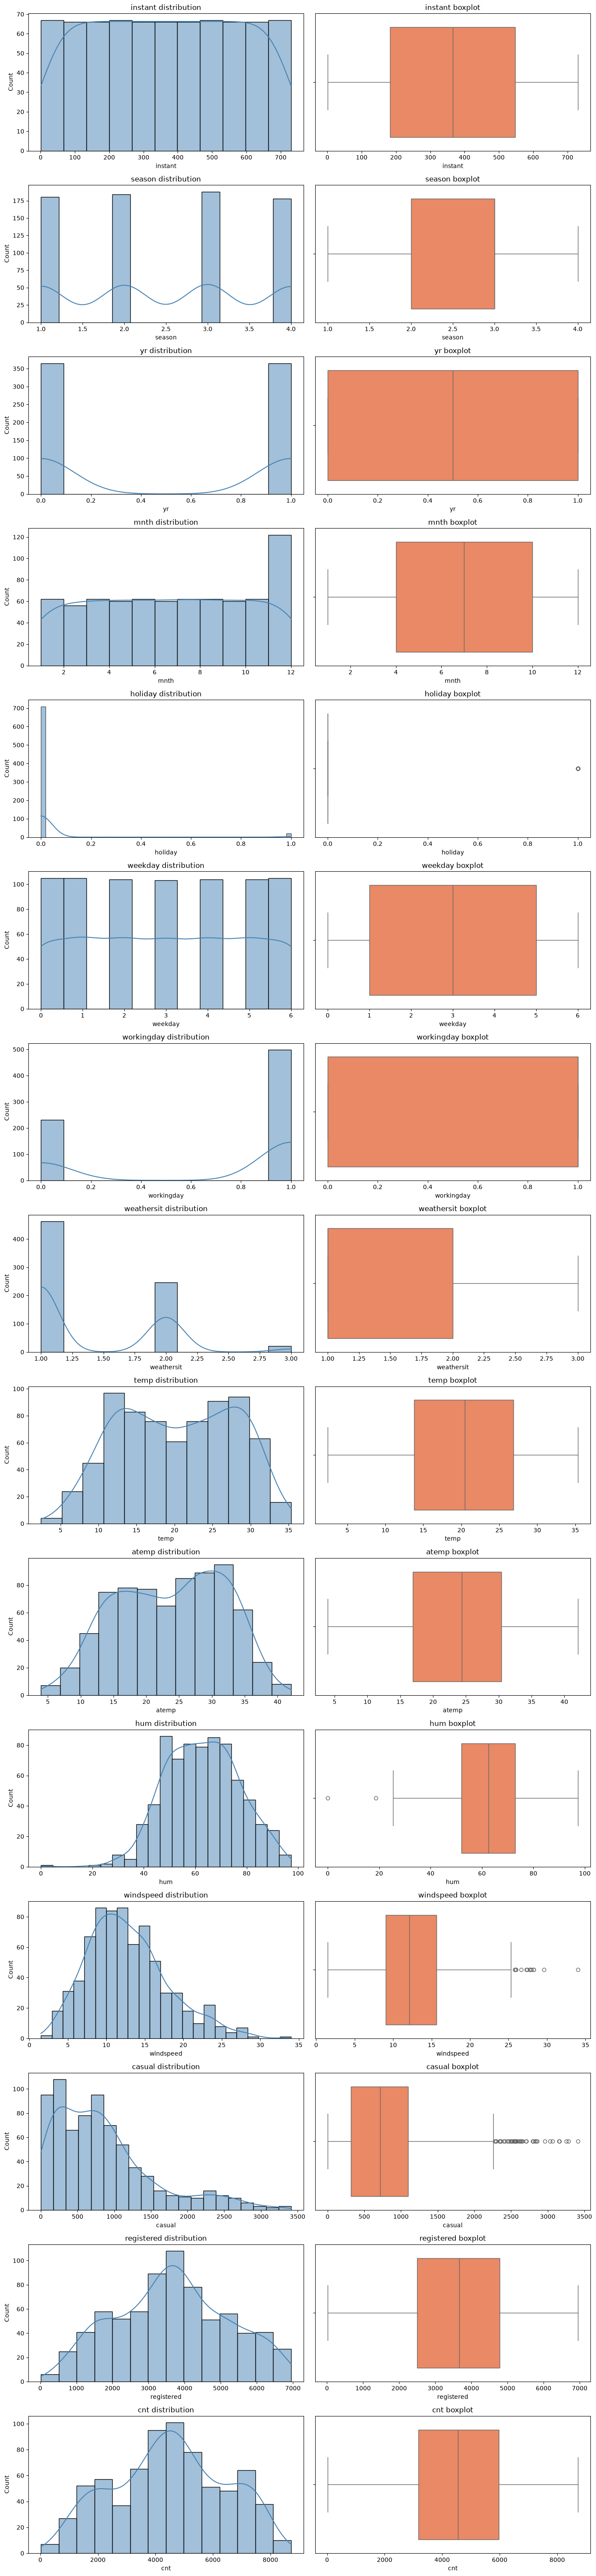

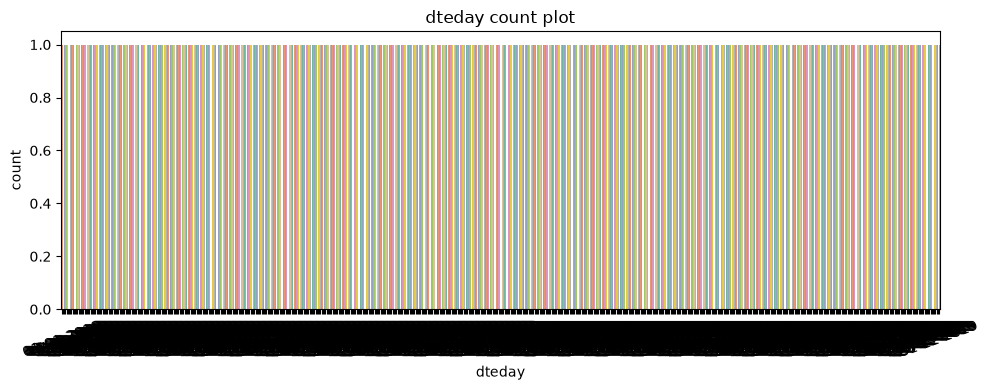

In [12]:
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4 * len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    sns.histplot(bike_df_copy[col], kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{col} distribution')
    sns.boxplot(x=bike_df_copy[col], ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'{col} boxplot')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(10, 4 * len(categorical_cols)))
if len(categorical_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, categorical_cols):
    order = bike_df_copy[col].value_counts().index
    sns.countplot(data=bike_df_copy, x=col, order=order, ax=ax, palette='Set2')
    ax.set_title(f'{col} count plot')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
capped_predictors = [col for col in numeric_cols if col != target_col]
bike_capped = bike_df_copy.copy()
outlier_caps = []

for col in capped_predictors:
    q1 = bike_df_copy[col].quantile(0.25)
    q3 = bike_df_copy[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    before_low = (bike_df_copy[col] < lower).sum()
    before_high = (bike_df_copy[col] > upper).sum()

    bike_capped[col] = bike_capped[col].clip(lower=lower, upper=upper)

    after_low = (bike_capped[col] < lower).sum()
    after_high = (bike_capped[col] > upper).sum()

    outlier_caps.append({
        'feature': col,
        'lower_cap': round(lower, 2),
        'upper_cap': round(upper, 2),
        'values_capped_low': int(before_low),
        'values_capped_high': int(before_high),
        'remaining_below_cap': int(after_low),
        'remaining_above_cap': int(after_high)
    })

outlier_capping_summary = pd.DataFrame(outlier_caps)    
display(outlier_capping_summary)

comparison_df = pd.DataFrame({
    'original_min': bike_df_copy[capped_predictors].min(),
    'capped_min': bike_capped[capped_predictors].min(),
    'original_max': bike_df_copy[capped_predictors].max(),
    'capped_max': bike_capped[capped_predictors].max()
})
display(comparison_df)

print('Outlier handling applied: IQR-based capping on numeric predictors, while price was left unchanged.')

,feature,lower_cap,upper_cap,values_capped_low,values_capped_high,remaining_below_cap,remaining_above_cap
0,instant,-363.50,1094.50,0,0,0,0
1,season,0.50,4.50,0,0,0,0
2,yr,-1.50,2.50,0,0,0,0
3,mnth,-5.00,19.00,0,0,0,0
4,holiday,0.00,0.00,0,21,0,0
5,weekday,-5.00,11.00,0,0,0,0
6,workingday,-1.50,2.50,0,0,0,0
7,weathersit,-0.50,3.50,0,0,0,0
8,temp,-5.79,46.48,0,0,0,0
9,atemp,-3.44,50.78,0,0,0,0


,original_min,capped_min,original_max,capped_max
instant,1.000000,1.000000,730.000000,730.000000
season,1.000000,1.000000,4.000000,4.000000
yr,0.000000,0.000000,1.000000,1.000000
mnth,1.000000,1.000000,12.000000,12.000000
holiday,0.000000,0.000000,1.000000,0.000000
weekday,0.000000,0.000000,6.000000,6.000000
workingday,0.000000,0.000000,1.000000,1.000000
weathersit,1.000000,1.000000,3.000000,3.000000
temp,2.424346,2.424346,35.328347,35.328347
atemp,3.953480,3.953480,42.044800,42.044800


Outlier handling applied: IQR-based capping on numeric predictors, while price was left unchanged.
